In [20]:
import pandas as pd

df = pd.read_csv('/kaggle/input/brisc2025/brisc2025/manifest.csv')

display(df.head())
print("Shape:", df.shape)
print(df.info())
print(df.size)

,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...


Shape: (15586, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15586 entries, 0 to 15585
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   relative_path    15586 non-null  object
 1   filename         15586 non-null  object
 2   task             15586 non-null  object
 3   split            15586 non-null  object
 4   index            15586 non-null  int64 
 5   tumor_code       15586 non-null  object
 6   tumor_label      15586 non-null  object
 7   plane_code       15586 non-null  object
 8   plane_label      15586 non-null  object
 9   sequence         15586 non-null  object
 10  is_mask          15586 non-null  bool  
 11  linked_image     4793 non-null   object
 12  width            15586 non-null  int64 
 13  height           15586 non-null  int64 
 14  file_size_bytes  15586 non-null  int64 
 15  sha256           15586 non-null  object
dtypes: bool(1), int64(4), object(11)
memory usage: 1.8+ MB
No

Found categories: ['pituitary', 'no_tumor', 'meningioma', 'glioma']


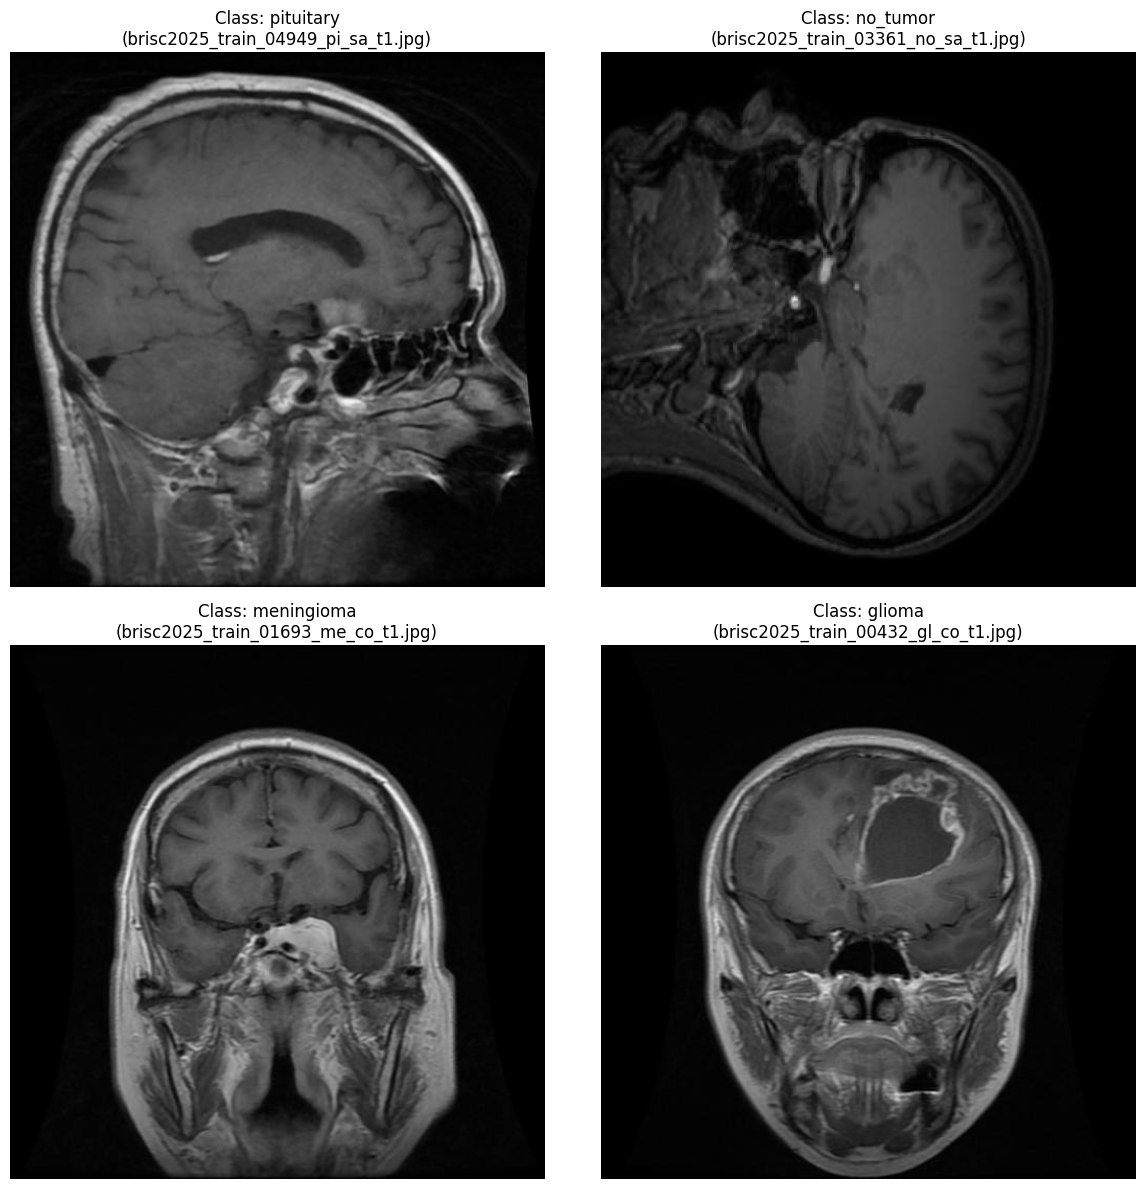

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

base_path = '/kaggle/input/brisc2025/brisc2025/classification_task/train'

try:
    categories = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    print(f"Found categories: {categories}")
    num_categories = len(categories)
    cols = 2 
    rows = (num_categories // cols) + (1 if num_categories % cols > 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 6))
    axes = axes.flatten()
    for i, category in enumerate(categories):
        cat_path = os.path.join(base_path, category)
        images = [img for img in os.listdir(cat_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            img_name = random.choice(images)
            img_path = os.path.join(cat_path, img_name)
            
            img = Image.open(img_path)
            axes[i].imshow(img, cmap='gray') # Brain scans are usually grayscale
            axes[i].set_title(f"Class: {category}\n({img_name})", fontsize=12)
            axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Path error! Please ensure the dataset 'brisc2025' is attached to the notebook.")

In [3]:
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

# Training preprocessing
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# Validation/Test preprocessing
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# Get labels
ds = datasets.ImageFolder(base_path)
labels = np.array([s[1] for s in ds.samples])
idx = np.arange(len(ds))

# 70% Train / 20% Validation / 10% Test
train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=labels, random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=1/3, stratify=labels[temp_idx], random_state=42
)

# Apply correct transforms to each split
train_ds = datasets.ImageFolder(base_path, transform=train_transform)
val_ds   = datasets.ImageFolder(base_path, transform=test_transform)
test_ds  = datasets.ImageFolder(base_path, transform=test_transform)

train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=16, shuffle=True)
val_loader   = DataLoader(Subset(val_ds, val_idx), batch_size=16, shuffle=False)
test_loader  = DataLoader(Subset(test_ds, test_idx), batch_size=16, shuffle=False)

print(f"Total: {len(idx)} | Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Total: 5000 | Train: 3500 | Val: 1000 | Test: 500


***Training and validation***

In [6]:
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu126
!pip install causal-conv1d --no-build-isolation
!pip install mamba-ssm --no-build-isolation --no-deps

Looking in indexes: https://download.pytorch.org/whl/cu126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.8/821.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 9.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: triton
    Found existing installation: triton 3.7.1
    Uninstalling triton-3.7.1:
      Successfully uninstalled triton-3.7.1
  Attempting uninstall: torch
    Found existing installation: torch 2.13.0
    Uninstalling torch-2.13.0:
      Successfully uninstalled torch-2.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mamba-ssm 2.3.2.post1 requires triton>=3.5.0, but you have triton 3.4.0 which is incompatible.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.


In [7]:
import torch
import torchvision
from mamba_ssm import Mamba

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Mamba: OK")

Torch: 2.8.0+cu126
Torchvision: 0.23.0+cu126
CUDA: True
GPU: Tesla T4
Mamba: OK


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from mamba_ssm import Mamba
    print("Mamba available")
except ImportError:
    print("Mamba not available - using fallback")

    class Mamba(nn.Module):
        def __init__(self, d_model, d_state, d_conv, expand):
            super().__init__()
            self.layer = nn.Linear(d_model, d_model)

        def forward(self, x):
            return self.layer(x)


class HybridMambaCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )

        self.mamba = Mamba(
            d_model=64,
            d_state=16,
            d_conv=4,
            expand=2
        )

        self.classifier = nn.Linear(
            64 * 64,
            num_classes
        )

    def forward(self, x):
        x = self.cnn(x)

        B, C, H, W = x.shape

        x = x.view(B, C, H * W)
        x = x.permute(0, 2, 1)

        x = self.mamba(x)

        x = x.reshape(B, -1)

        return self.classifier(x)


model = HybridMambaCNN(
    num_classes=len(train_ds.classes)
).to(device)

print("Model:", model.__class__.__name__)
print("Classes:", train_ds.classes)
print("Device:", device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total
    train_loss /= len(train_loader)

    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print("\nTraining completed!")

print(
    f"Train: {len(train_idx)} | "
    f"Validation: {len(val_idx)} | "
    f"Test: {len(test_idx)}"
)

Mamba available
Model: HybridMambaCNN
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Device: cuda
Epoch 01/15 | Train Loss: 0.9929 | Train Acc: 62.97% | Val Loss: 0.7539 | Val Acc: 69.40%
Epoch 02/15 | Train Loss: 0.6695 | Train Acc: 73.69% | Val Loss: 0.6490 | Val Acc: 73.10%
Epoch 03/15 | Train Loss: 0.5934 | Train Acc: 77.26% | Val Loss: 0.5874 | Val Acc: 77.00%
Epoch 04/15 | Train Loss: 0.5387 | Train Acc: 79.17% | Val Loss: 0.5535 | Val Acc: 77.50%
Epoch 05/15 | Train Loss: 0.5293 | Train Acc: 80.06% | Val Loss: 0.5307 | Val Acc: 76.90%
Epoch 06/15 | Train Loss: 0.5206 | Train Acc: 80.37% | Val Loss: 0.5212 | Val Acc: 78.20%
Epoch 07/15 | Train Loss: 0.4928 | Train Acc: 81.06% | Val Loss: 0.5064 | Val Acc: 79.50%
Epoch 08/15 | Train Loss: 0.4850 | Train Acc: 81.69% | Val Loss: 0.5028 | Val Acc: 79.30%
Epoch 09/15 | Train Loss: 0.4552 | Train Acc: 82.74% | Val Loss: 0.4839 | Val Acc: 80.10%
Epoch 10/15 | Train Loss: 0.4623 | Train Acc: 82.83% | Val Loss: 0.4504 | Val Ac

***Testing the data***

In [10]:
from sklearn.metrics import classification_report, accuracy_score
import torch

model.eval()
test_labels, test_preds = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(labels.numpy())

print("\n" + "="*25 + " TEST RESULTS " + "="*25)
print(f"Test Samples : {len(test_labels)}")
print(f"Test Accuracy: {accuracy_score(test_labels, test_preds):.2%}\n")

print(classification_report(
    test_labels,
    test_preds,
    target_names=train_ds.classes,
    zero_division=0
))


========================= TEST RESULTS =========================
Test Samples : 500
Test Accuracy: 84.40%

              precision    recall  f1-score   support

      glioma       0.80      0.73      0.76       115
  meningioma       0.75      0.75      0.75       133
    no_tumor       0.95      0.93      0.94       106
   pituitary       0.88      0.95      0.91       146

    accuracy                           0.84       500
   macro avg       0.85      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



In [36]:
torch.save(
    model.state_dict(),
    "/kaggle/working/model1_hybrid_cnn_mamba.pth"
)

print("Model 1 saved successfully")

Model 1 saved successfully


***Metrics of the Training,validation and testing***


==================== TRAINING RESULTS ====================
Accuracy: 86.54%
              precision    recall  f1-score   support

      glioma       0.81      0.84      0.82       803
  meningioma       0.79      0.76      0.77       930
    no_tumor       0.95      0.91      0.93       747
   pituitary       0.92      0.95      0.94      1020

    accuracy                           0.87      3500
   macro avg       0.87      0.86      0.86      3500
weighted avg       0.87      0.87      0.86      3500


==================== VALIDATION RESULTS ====================
Accuracy: 84.80%
              precision    recall  f1-score   support

      glioma       0.79      0.79      0.79       229
  meningioma       0.78      0.72      0.75       266
    no_tumor       0.96      0.90      0.93       214
   pituitary       0.87      0.98      0.92       291

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      

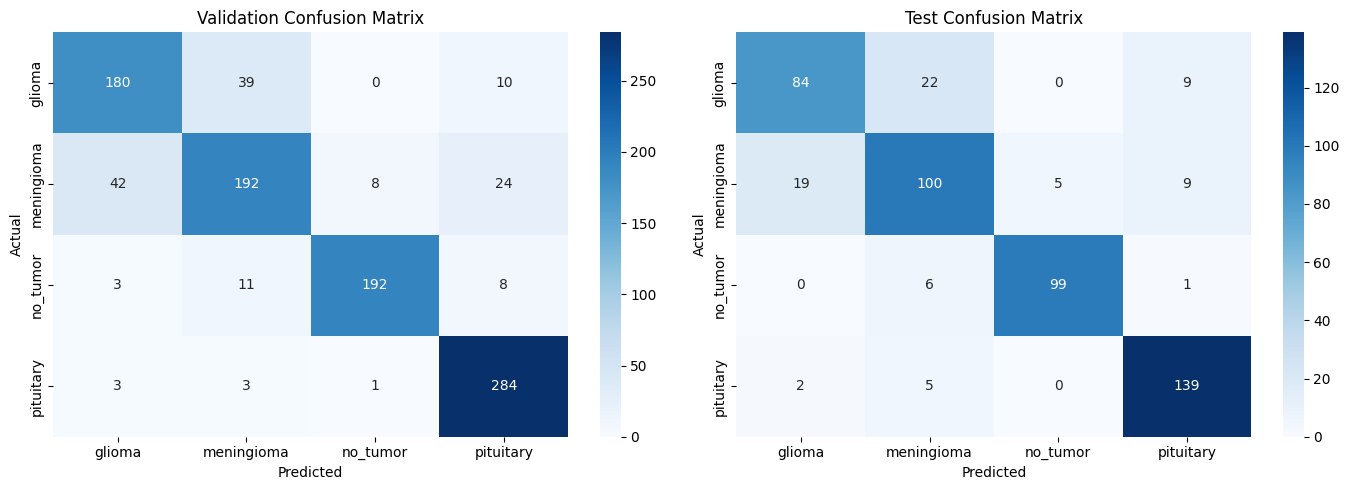

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate(loader):
    model.eval()
    labels, preds = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())

    return np.array(labels), np.array(preds)

def print_all_metrics(model, train_loader, val_loader, test_loader, class_names):
    train_labels, train_preds = evaluate(train_loader)
    val_labels, val_preds = evaluate(val_loader)
    test_labels, test_preds = evaluate(test_loader)

    print("\n" + "="*20 + " TRAINING RESULTS " + "="*20)
    print(f"Accuracy: {accuracy_score(train_labels, train_preds):.2%}")
    print(classification_report(
        train_labels, train_preds,
        target_names=class_names,
        zero_division=0
    ))

    print("\n" + "="*20 + " VALIDATION RESULTS " + "="*20)
    print(f"Accuracy: {accuracy_score(val_labels, val_preds):.2%}")
    print(classification_report(
        val_labels, val_preds,
        target_names=class_names,
        zero_division=0
    ))

    print("\n" + "="*20 + " TEST RESULTS " + "="*20)
    print(f"Accuracy: {accuracy_score(test_labels, test_preds):.2%}")
    print(classification_report(
        test_labels, test_preds,
        target_names=class_names,
        zero_division=0
    ))

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        confusion_matrix(val_labels, val_preds),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax[0]
    )
    ax[0].set_title("Validation Confusion Matrix")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")

    sns.heatmap(
        confusion_matrix(test_labels, test_preds),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax[1]
    )
    ax[1].set_title("Test Confusion Matrix")
    ax[1].set_xlabel("Predicted")
    ax[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

print_all_metrics(
    model,
    train_loader,
    val_loader,
    test_loader,
    train_ds.classes
)

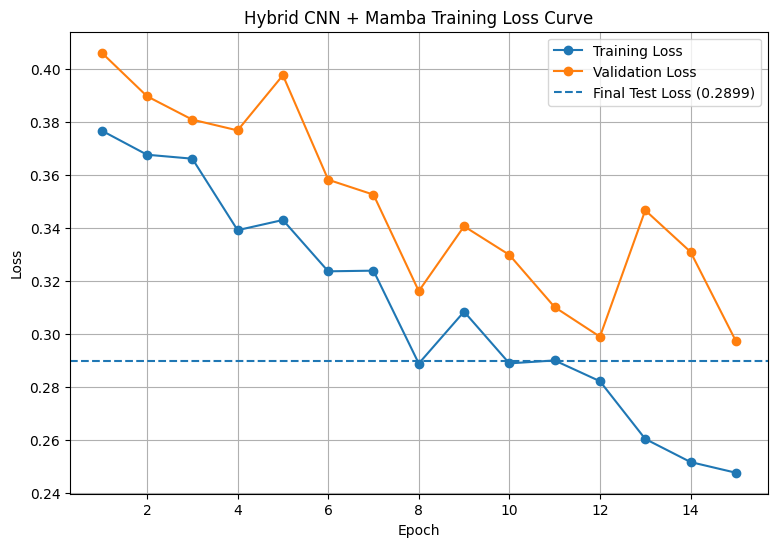

In [13]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

model.eval()
test_loss = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

test_loss /= len(test_loader)

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.axhline(
    y=test_loss,
    linestyle='--',
    label=f'Final Test Loss ({test_loss:.4f})'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid CNN + Mamba Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
batch = next(iter(train_loader))

print("Number of items returned:", len(batch))

for i, item in enumerate(batch):
    print(i, item.shape if hasattr(item, "shape") else type(item))

Number of items returned: 2
0 torch.Size([16, 3, 128, 128])
1 torch.Size([16])


In [24]:
import os

DATA_DIR = "/kaggle/input/brisc2025/brisc2025"

for folder in ["classification_task", "segmentation_task"]:
    path = os.path.join(DATA_DIR, folder)

    print("\n" + "=" * 60)
    print(folder)
    print("=" * 60)

    for root, dirs, files in os.walk(path):
        print("\nFolder:", root)
        print("Subfolders:", dirs[:10])
        print("Files:", files[:10])

        if root.count(os.sep) > path.count(os.sep) + 2:
            dirs[:] = []


classification_task

Folder: /kaggle/input/brisc2025/brisc2025/classification_task
Subfolders: ['test', 'train']
Files: []

Folder: /kaggle/input/brisc2025/brisc2025/classification_task/test
Subfolders: ['pituitary', 'no_tumor', 'meningioma', 'glioma']
Files: []

Folder: /kaggle/input/brisc2025/brisc2025/classification_task/test/pituitary
Subfolders: []
Files: ['brisc2025_test_00949_pi_sa_t1.jpg', 'brisc2025_test_00799_pi_ax_t1.jpg', 'brisc2025_test_00705_pi_ax_t1.jpg', 'brisc2025_test_01000_pi_sa_t1.jpg', 'brisc2025_test_00829_pi_co_t1.jpg', 'brisc2025_test_00735_pi_ax_t1.jpg', 'brisc2025_test_00704_pi_ax_t1.jpg', 'brisc2025_test_00707_pi_ax_t1.jpg', 'brisc2025_test_00743_pi_ax_t1.jpg', 'brisc2025_test_00834_pi_co_t1.jpg']

Folder: /kaggle/input/brisc2025/brisc2025/classification_task/test/no_tumor
Subfolders: []
Files: ['brisc2025_test_00643_no_co_t1.jpg', 'brisc2025_test_00602_no_ax_t1.jpg', 'brisc2025_test_00573_no_ax_t1.jpg', 'brisc2025_test_00677_no_sa_t1.jpg', 'brisc2025_test_0

In [30]:
import os,random,numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split

ROOT="/kaggle/input/brisc2025/brisc2025/segmentation_task"
IMG_SIZE=224
BATCH=8
EPOCHS=20
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

def pairs(img_dir,mask_dir):
    masks={os.path.splitext(x)[0]:os.path.join(mask_dir,x) for x in os.listdir(mask_dir)}
    return [(os.path.join(img_dir,x),masks[os.path.splitext(x)[0]]) for x in os.listdir(img_dir) if os.path.splitext(x)[0] in masks]

class DS(Dataset):
    def __init__(self,p,aug=False): self.p,self.aug=p,aug
    def __len__(self): return len(self.p)
    def __getitem__(self,i):
        x=Image.open(self.p[i][0]).convert("RGB").resize((IMG_SIZE,IMG_SIZE))
        y=Image.open(self.p[i][1]).convert("L").resize((IMG_SIZE,IMG_SIZE),Image.NEAREST)
        x=np.array(x,dtype=np.float32)/255
        y=(np.array(y)>0).astype(np.float32)
        if self.aug and random.random()<.5:
            x=np.fliplr(x).copy()
            y=np.fliplr(y).copy()
        return torch.tensor(x).permute(2,0,1),torch.tensor(y).unsqueeze(0)

train_p=pairs(f"{ROOT}/train/images",f"{ROOT}/train/masks")
test_p=pairs(f"{ROOT}/test/images",f"{ROOT}/test/masks")
train_p,val_p=train_test_split(train_p,test_size=.2,random_state=42)

tr=DataLoader(DS(train_p,True),BATCH,shuffle=True,num_workers=2)
va=DataLoader(DS(val_p),BATCH,num_workers=2)
te=DataLoader(DS(test_p),BATCH,num_workers=2)

class Conv(nn.Module):
    def __init__(self,a,b):
        super().__init__()
        self.c=nn.Sequential(
            nn.Conv2d(a,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU(),
            nn.Conv2d(b,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU()
        )
    def forward(self,x): return self.c(x)

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=Conv(3,32);self.e2=Conv(32,64);self.e3=Conv(64,128);self.e4=Conv(128,256)
        self.p=nn.MaxPool2d(2);self.b=Conv(256,512)
        self.u4=nn.ConvTranspose2d(512,256,2,2);self.d4=Conv(512,256)
        self.u3=nn.ConvTranspose2d(256,128,2,2);self.d3=Conv(256,128)
        self.u2=nn.ConvTranspose2d(128,64,2,2);self.d2=Conv(128,64)
        self.u1=nn.ConvTranspose2d(64,32,2,2);self.d1=Conv(64,32)
        self.out=nn.Conv2d(32,1,1)
    def forward(self,x):
        e1=self.e1(x);e2=self.e2(self.p(e1));e3=self.e3(self.p(e2));e4=self.e4(self.p(e3))
        b=self.b(self.p(e4))
        d4=self.d4(torch.cat([self.u4(b),e4],1))
        d3=self.d3(torch.cat([self.u3(d4),e3],1))
        d2=self.d2(torch.cat([self.u2(d3),e2],1))
        d1=self.d1(torch.cat([self.u1(d2),e1],1))
        return self.out(d1)

def loss_fn(p,y):
    bce=nn.functional.binary_cross_entropy_with_logits(p,y)
    p=torch.sigmoid(p)
    dice=(2*(p*y).sum((1,2,3))+1e-6)/(p.sum((1,2,3))+y.sum((1,2,3))+1e-6)
    return bce+1-dice.mean()

def metrics(p,y):
    p=(torch.sigmoid(p)>.5).float()
    inter=(p*y).sum((1,2,3))
    dice=(2*inter+1e-6)/(p.sum((1,2,3))+y.sum((1,2,3))+1e-6)
    iou=(inter+1e-6)/(p.sum((1,2,3))+y.sum((1,2,3))-inter+1e-6)
    return dice.mean().item(),iou.mean().item()

model2=Model2().to(device)
opt=torch.optim.AdamW(model2.parameters(),lr=1e-3,weight_decay=1e-4)
best=0

for epoch in range(EPOCHS):
    model2.train()
    train_loss=0
    for x,y in tr:
        x,y=x.to(device),y.to(device)
        opt.zero_grad()
        l=loss_fn(model2(x),y)
        l.backward()
        opt.step()
        train_loss+=l.item()*x.size(0)

    train_loss/=len(tr.dataset)
    model2.eval()
    val_loss=d=i=0

    with torch.no_grad():
        for x,y in va:
            x,y=x.to(device),y.to(device)
            p=model2(x)
            l=loss_fn(p,y)
            a,b=metrics(p,y)
            val_loss+=l.item()*x.size(0)
            d+=a*x.size(0)
            i+=b*x.size(0)

    val_loss/=len(va.dataset)
    d/=len(va.dataset)
    i/=len(va.dataset)

    if d>best:
        best=d
        torch.save(model2.state_dict(),"/kaggle/working/model2_unet.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Dice {d:.4f} | IoU {i:.4f}")

model2.load_state_dict(torch.load("/kaggle/working/model2_unet.pth",map_location=device))
model2.eval()

def evaluate(loader):
    d=i=0
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            a,b=metrics(model2(x),y)
            d+=a*x.size(0)
            i+=b*x.size(0)
    return d/len(loader.dataset),i/len(loader.dataset)

vd,vi=evaluate(va)
td,ti=evaluate(te)

print(f"Validation: Dice={vd:.4f}, IoU={vi:.4f}")
print(f"Test: Dice={td:.4f}, IoU={ti:.4f}")

Epoch 1/20 | Train Loss 0.9808 | Val Loss 0.6900 | Dice 0.4444 | IoU 0.3240
Epoch 2/20 | Train Loss 0.5228 | Val Loss 0.5840 | Dice 0.5135 | IoU 0.3979
Epoch 3/20 | Train Loss 0.4493 | Val Loss 0.5158 | Dice 0.5663 | IoU 0.4430
Epoch 4/20 | Train Loss 0.4119 | Val Loss 0.4018 | Dice 0.6575 | IoU 0.5525
Epoch 5/20 | Train Loss 0.3749 | Val Loss 0.3754 | Dice 0.6824 | IoU 0.5740
Epoch 6/20 | Train Loss 0.3531 | Val Loss 0.3758 | Dice 0.6773 | IoU 0.5782
Epoch 7/20 | Train Loss 0.3336 | Val Loss 0.3769 | Dice 0.6842 | IoU 0.5697
Epoch 8/20 | Train Loss 0.3102 | Val Loss 0.3386 | Dice 0.7157 | IoU 0.6057
Epoch 9/20 | Train Loss 0.3025 | Val Loss 0.3053 | Dice 0.7372 | IoU 0.6383
Epoch 10/20 | Train Loss 0.2959 | Val Loss 0.3162 | Dice 0.7288 | IoU 0.6247
Epoch 11/20 | Train Loss 0.2843 | Val Loss 0.2880 | Dice 0.7522 | IoU 0.6504
Epoch 12/20 | Train Loss 0.2833 | Val Loss 0.3460 | Dice 0.7018 | IoU 0.6044
Epoch 13/20 | Train Loss 0.2760 | Val Loss 0.2895 | Dice 0.7496 | IoU 0.6509
Epoch 14

MODEL 2 — U-NET
Dice        : 0.8215
IoU         : 0.6970
Accuracy    : 0.9926
Precision   : 0.8412
Recall      : 0.8027
Specificity : 0.9967
F1 Score    : 0.8215


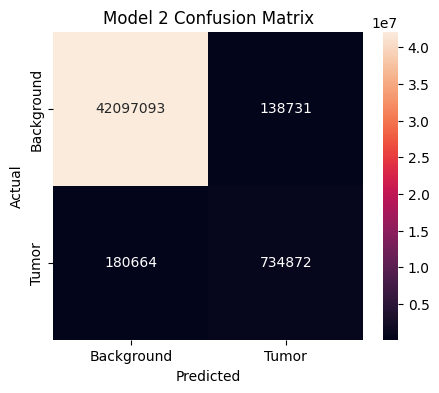

In [32]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

model2.eval()
tp=tn=fp=fn=0

with torch.no_grad():
    for x,y in te:
        x,y=x.to(device),y.to(device)
        pred=(torch.sigmoid(model2(x))>0.5).float()
        tp+=((pred==1)&(y==1)).sum().item()
        tn+=((pred==0)&(y==0)).sum().item()
        fp+=((pred==1)&(y==0)).sum().item()
        fn+=((pred==0)&(y==1)).sum().item()

dice=2*tp/(2*tp+fp+fn+1e-8)
iou=tp/(tp+fp+fn+1e-8)
precision=tp/(tp+fp+1e-8)
recall=tp/(tp+fn+1e-8)
specificity=tn/(tn+fp+1e-8)
accuracy=(tp+tn)/(tp+tn+fp+fn+1e-8)
f1=2*precision*recall/(precision+recall+1e-8)

print("MODEL 2 — U-NET")
print(f"Dice        : {dice:.4f}")
print(f"IoU         : {iou:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")

cm=np.array([[tn,fp],[fn,tp]])

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Background","Tumor"],
    yticklabels=["Background","Tumor"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 Confusion Matrix")
plt.show()

In [46]:
import torch
import numpy as np

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2=Model2().to(device)
model2.load_state_dict(torch.load("/kaggle/working/model2_unet.pth",map_location=device))
model2.eval()

def seg_accuracy(loader):
    correct=total=0
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            pred=(torch.sigmoid(model2(x))>0.5).float()
            correct+=(pred==y).sum().item()
            total+=y.numel()
    return 100*correct/total

print("MODEL 2 — U-NET")
print(f"Train Accuracy: {seg_accuracy(tr):.2f}%")
print(f"Val Accuracy:   {seg_accuracy(va):.2f}%")
print(f"Test Accuracy:  {seg_accuracy(te):.2f}%")

MODEL 2 — U-NET
Train Accuracy: 99.38%
Val Accuracy:   99.34%
Test Accuracy:  99.26%


In [41]:
import os,cv2,numpy as np,torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,random_split
from PIL import Image

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT="/kaggle/input/brisc2025/brisc2025"
CLS_ROOT=f"{ROOT}/classification_task"
IMG_SIZE=224
BATCH=8
EPOCHS=15
NUM_CLASSES=4
classes=["glioma","meningioma","pituitary","no_tumor"]
class_to_idx={c:i for i,c in enumerate(classes)}

model2=Model2().to(device)
model2.load_state_dict(torch.load("/kaggle/working/model2_unet.pth",map_location=device))
model2.eval()

class MorphDataset(Dataset):
    def __init__(self,root):
        self.samples=[]
        for c in classes:
            folder=os.path.join(root,c)
            for f in os.listdir(folder):
                if f.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(folder,f),class_to_idx[c]))
    def __len__(self): return len(self.samples)
    def __getitem__(self,i):
        path,label=self.samples[i]
        img=Image.open(path).convert("RGB").resize((IMG_SIZE,IMG_SIZE))
        x=torch.tensor(np.array(img,dtype=np.float32)/255).permute(2,0,1)
        return x,label,path

full_train_ds=MorphDataset(f"{CLS_ROOT}/train")
test_ds=MorphDataset(f"{CLS_ROOT}/test")
train_size=int(0.8*len(full_train_ds))
val_size=len(full_train_ds)-train_size
train_ds,val_ds=random_split(full_train_ds,[train_size,val_size],generator=torch.Generator().manual_seed(42))

print(f"Total: {len(full_train_ds)} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=2)
val_loader=DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=2)
test_loader=DataLoader(test_ds,batch_size=BATCH,shuffle=False,num_workers=2)

def morphology(mask):
    mask=(mask>0.5).astype(np.uint8)
    area=mask.sum()
    ys,xs=np.where(mask)
    if len(xs)==0:return np.zeros(6,dtype=np.float32)
    width=xs.max()-xs.min()+1
    height=ys.max()-ys.min()+1
    aspect=width/(height+1e-6)
    contours,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        contour=max(contours,key=cv2.contourArea)
        perimeter=cv2.arcLength(contour,True)
        contour_area=cv2.contourArea(contour)
        circularity=4*np.pi*contour_area/(perimeter**2+1e-6)
    else:
        perimeter=circularity=0
    return np.array([area/(IMG_SIZE*IMG_SIZE),perimeter/IMG_SIZE,width/IMG_SIZE,height/IMG_SIZE,aspect,circularity],dtype=np.float32)

class MorphCNNMamba(nn.Module):
    def __init__(self,num_classes=4,morph_features=6):
        super().__init__()
        self.cnn=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.AdaptiveAvgPool2d((8,8))
        )
        self.mamba=Mamba(d_model=64,d_state=16,d_conv=4,expand=2)
        self.morph=nn.Sequential(nn.Linear(morph_features,32),nn.ReLU(),nn.Linear(32,32),nn.ReLU())
        self.classifier=nn.Sequential(nn.Linear(4096+32,128),nn.ReLU(),nn.Dropout(0.3),nn.Linear(128,num_classes))

    def forward(self,x,m):
        f=self.cnn(x)
        B,C,H,W=f.shape
        f=f.view(B,C,H*W).permute(0,2,1)
        f=self.mamba(f).reshape(B,-1)
        m=self.morph(m)
        return self.classifier(torch.cat([f,m],dim=1))

model3=MorphCNNMamba(NUM_CLASSES).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(model3.parameters(),lr=1e-4,weight_decay=1e-4)

def get_morphology(x):
    with torch.no_grad():
        mask=torch.sigmoid(model2(x)).cpu().numpy()
    return torch.tensor(np.array([morphology(m[0]) for m in mask]),dtype=torch.float32,device=device)

for epoch in range(EPOCHS):
    model3.train()
    correct=total=loss_sum=0

    for x,y,_ in train_loader:
        x,y=x.to(device),y.to(device)
        m=get_morphology(x)
        optimizer.zero_grad()
        out=model3(x,m)
        loss=criterion(out,y)
        loss.backward()
        optimizer.step()
        loss_sum+=loss.item()
        correct+=(out.argmax(1)==y).sum().item()
        total+=y.size(0)

    train_acc=100*correct/total
    train_loss=loss_sum/len(train_loader)

    model3.eval()
    val_correct=val_total=val_loss_sum=0

    with torch.no_grad():
        for x,y,_ in val_loader:
            x,y=x.to(device),y.to(device)
            m=get_morphology(x)
            out=model3(x,m)
            loss=criterion(out,y)
            val_loss_sum+=loss.item()
            val_correct+=(out.argmax(1)==y).sum().item()
            val_total+=y.size(0)

    val_acc=100*val_correct/val_total
    val_loss=val_loss_sum/len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

model3.eval()
correct=total=0

with torch.no_grad():
    for x,y,_ in test_loader:
        x,y=x.to(device),y.to(device)
        m=get_morphology(x)
        out=model3(x,m)
        correct+=(out.argmax(1)==y).sum().item()
        total+=y.size(0)

test_acc=100*correct/total
print(f"\nTest Accuracy: {test_acc:.2f}%")

x,y,path=next(iter(test_loader))
x=x.to(device)

with torch.no_grad():
    m=get_morphology(x)
    out=model3(x,m)
    prob=torch.softmax(out,1)
    pred=out.argmax(1)

for j in range(min(5,len(x))):
    f=m[j].cpu().numpy()
    print(f"\nImage: {os.path.basename(path[j])}")
    print(f"Prediction: {classes[pred[j].item()]}")
    print(f"Confidence: {prob[j,pred[j]].item()*100:.2f}%")
    print(f"Tumor Area: {f[0]*100:.2f}%")
    print(f"Perimeter: {f[1]:.3f}")
    print(f"Width: {f[2]:.3f}")
    print(f"Height: {f[3]:.3f}")
    print(f"Aspect Ratio: {f[4]:.3f}")
    print(f"Circularity: {f[5]:.3f}")

Total: 5000 | Train: 4000 | Val: 1000 | Test: 1000
Epoch 1/15 | Train Loss: 0.8400 | Train Acc: 66.95% | Val Loss: 0.5695 | Val Acc: 78.90%
Epoch 2/15 | Train Loss: 0.5475 | Train Acc: 78.70% | Val Loss: 0.4786 | Val Acc: 83.10%
Epoch 3/15 | Train Loss: 0.4594 | Train Acc: 81.80% | Val Loss: 0.4292 | Val Acc: 84.50%
Epoch 4/15 | Train Loss: 0.4036 | Train Acc: 84.25% | Val Loss: 0.4033 | Val Acc: 84.70%
Epoch 5/15 | Train Loss: 0.3557 | Train Acc: 87.00% | Val Loss: 0.3364 | Val Acc: 87.40%
Epoch 6/15 | Train Loss: 0.3138 | Train Acc: 88.60% | Val Loss: 0.3571 | Val Acc: 88.10%
Epoch 7/15 | Train Loss: 0.2841 | Train Acc: 88.97% | Val Loss: 0.3168 | Val Acc: 88.70%
Epoch 8/15 | Train Loss: 0.2651 | Train Acc: 90.10% | Val Loss: 0.2572 | Val Acc: 89.60%
Epoch 9/15 | Train Loss: 0.2251 | Train Acc: 91.45% | Val Loss: 0.3066 | Val Acc: 88.50%
Epoch 10/15 | Train Loss: 0.2050 | Train Acc: 92.20% | Val Loss: 0.2488 | Val Acc: 90.20%
Epoch 11/15 | Train Loss: 0.1995 | Train Acc: 92.42% | Val

MODEL 3 — MORPHOLOGY-AWARE CNN-MAMBA
Accuracy  : 0.8950
Precision : 0.9021
Recall    : 0.8950
F1 Score  : 0.8949

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.78      0.86       254
  meningioma       0.82      0.88      0.85       306
   pituitary       0.97      0.96      0.97       300
    no_tumor       0.83      0.99      0.90       140

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.89      1000
weighted avg       0.90      0.90      0.89      1000



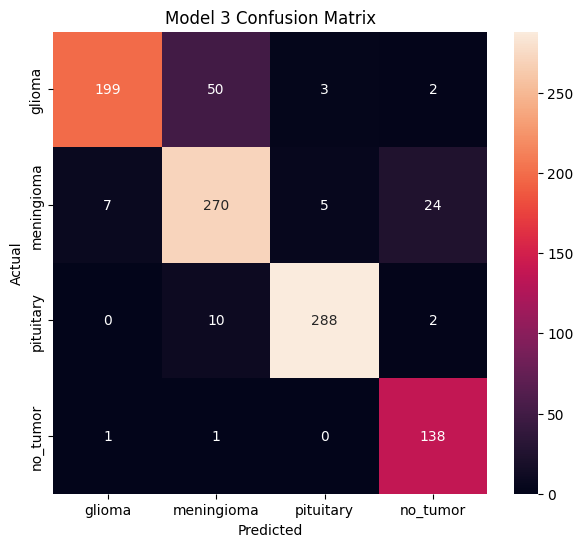

In [47]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model3.eval()
y_true=[]
y_pred=[]

with torch.no_grad():
    for x,y,_ in test_loader:
        x=x.to(device)
        m=get_morphology(x)
        out=model3(x,m)
        pred=out.argmax(1).cpu().numpy()
        y_pred.extend(pred)
        y_true.extend(y.numpy())

y_true=np.array(y_true)
y_pred=np.array(y_pred)

accuracy=accuracy_score(y_true,y_pred)
precision=precision_score(y_true,y_pred,average="weighted",zero_division=0)
recall=recall_score(y_true,y_pred,average="weighted",zero_division=0)
f1=f1_score(y_true,y_pred,average="weighted",zero_division=0)

cm=confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

print("MODEL 3 — MORPHOLOGY-AWARE CNN-MAMBA")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    zero_division=0
))

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 3 Confusion Matrix")
plt.show()

In [48]:
torch.save(
    model3.state_dict(),
    "/kaggle/working/model3_morphology_cnn_mamba.pth"
)

print("Model 3 saved successfully")

Model 3 saved successfully


In [49]:
model3=MorphCNNMamba(NUM_CLASSES).to(device)
model3.load_state_dict(torch.load("/kaggle/working/model3_morphology_cnn_mamba.pth",map_location=device))
model3.eval()

def cls_accuracy(loader):
    correct=total=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(device),y.to(device)
            m=get_morphology(x)
            out=model3(x,m)
            correct+=(out.argmax(1)==y).sum().item()
            total+=y.size(0)
    return 100*correct/total

print("\nMODEL 3 — MORPHOLOGY-AWARE CNN-MAMBA")
print(f"Train Accuracy: {cls_accuracy(train_loader):.2f}%")
print(f"Val Accuracy:   {cls_accuracy(val_loader):.2f}%")
print(f"Test Accuracy:  {cls_accuracy(test_loader):.2f}%")


MODEL 3 — MORPHOLOGY-AWARE CNN-MAMBA
Train Accuracy: 95.75%
Val Accuracy:   92.00%
Test Accuracy:  89.50%
